In [37]:
import pandas as pd
import pyarrow.parquet as pq

# Set display option to avoid scientific notation
pd.set_option('display.float_format', '{:.10f}'.format)

pq_path = r"parquet_files_dataset/compress/compress-gzip-all-events-run0.parquet"
start, stop = 1, 20

pf = pq.ParquetFile(pq_path)
tbl = pf.read()
df = tbl.to_pandas().iloc[start:stop]

display(df)

,t_sec,dt_sec,cpu,event_id
1,31591.4913498300,0.0000005360,1,33
2,31591.4913506380,0.0000008080,1,34
3,31591.4913512700,0.0000006320,2,23
4,31591.4913517800,0.0000005100,1,20
5,31591.4913521580,0.0000003780,2,18
6,31591.4913524730,0.0000003150,2,18
7,31591.4913527640,0.0000002910,2,25
8,31591.4913528860,0.0000001220,1,19
9,31591.4913533560,0.0000004700,1,20
10,31591.4913536500,0.0000002940,1,19


In [ ]:
import numpy as np

def inspect_npz(npz_path, n=3, k=15):
    d = np.load(npz_path)
    event = d["event"]
    dt    = d["dt"]
    cpu   = d["cpu"]

    print("=== SHAPES ===")
    print("event:", event.shape, event.dtype)
    print("dt   :", dt.shape, dt.dtype)
    print("cpu  :", cpu.shape, cpu.dtype)

    B, L = event.shape

    print("\n=== SAMPLE SEQUENCES (first 20 tokens) ===")
    for i in range(min(n, B)):
        print(f"\n-- seq {i} --")
        print("event:", event[i, :20].tolist())
        print("dt   :", dt[i, :20].tolist())
        print("cpu  :", cpu[i, :20].tolist())

    print("\n=== BASIC STATS ===")
    print("event min/max:", int(event.min()), int(event.max()))
    print("dt    min/max:", int(dt.min()), int(dt.max()))
    print("cpu   min/max:", int(cpu.min()), int(cpu.max()))

    ev_counts = np.bincount(event.reshape(-1))
    top = np.argsort(ev_counts)[::-1][:k]

    print(f"\nTop {k} events:")
    for eid in top:
        if ev_counts[eid] == 0:
            break
        print(f"  event_id={eid}: {int(ev_counts[eid])}")

    cpu_counts = np.bincount(cpu.reshape(-1))
    print("\nCPU distribution:")
    for c in range(len(cpu_counts)):
        if cpu_counts[c] > 0:
            print(f"  cpu {c}: {int(cpu_counts[c])}")

    dt_flat = dt.reshape(-1).astype(np.int64)
    print("\nDT bucket stats:")
    print(
        "  min=", int(dt_flat.min()),
        "max=", int(dt_flat.max()),
        "mean=", float(dt_flat.mean()),
    )

In [ ]:
npz_path = r"window_shards\compress-gzip\train\run00_shard0000.npz"
inspect_npz(npz_path, n=5, k=20)

In [26]:
npz_path = r"window_shards\compress-gzip\train\run00_shard0004.npz"
inspect_npz(npz_path, n=5, k=20)

=== SHAPES ===
event: (99771, 200) int32
dt   : (99771, 200) uint8
cpu  : (99771, 200) uint8

=== SAMPLE SEQUENCES (first 20 tokens) ===

-- seq 0 --
event: [1, 1, 1, 1, 18, 18, 24, 25, 21, 22, 23, 17, 0, 0, 0, 0, 0, 0, 0, 33]
dt   : [71, 73, 71, 70, 71, 53, 56, 63, 67, 60, 69, 139, 78, 70, 69, 69, 69, 70, 70, 61]
cpu  : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]

-- seq 1 --
event: [33, 34, 16, 23, 21, 22, 18, 18, 25, 1, 1, 1, 1, 1, 1, 1, 3, 17, 16, 2]
dt   : [61, 71, 63, 53, 63, 61, 63, 53, 61, 77, 71, 72, 71, 71, 70, 71, 73, 67, 110, 62]
cpu  : [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

-- seq 2 --
event: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 33, 34, 16, 23]
dt   : [62, 61, 66, 61, 61, 61, 61, 61, 60, 56, 68, 68, 68, 69, 68, 68, 62, 71, 64, 48]
cpu  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]

-- seq 3 --
event: [5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 18, 18, 24, 25, 21, 22, 23]
dt   : [58, 58, 58, 58, 59, 58, 58, 59

In [27]:
import json
import sys
from pathlib import Path

def sum_counts(json_path: str) -> int:
    json_path = Path(json_path)
    if not json_path.exists():
        raise FileNotFoundError(f"File not found: {json_path}")

    with open(json_path, "r") as f:
        data = json.load(f)

    total = 0
    for key, items in data.items():
        for obj in items:
            total += obj.get("count", 0)

    return total

In [28]:
import json
from pathlib import Path

# Path to your JSON file
json_path = "./metadata_all_events/event_schemas.json"
# Load and sum counts
data = json.loads(Path(json_path).read_text())

total_count = 0
for key, items in data.items():
    for obj in items:
        total_count += obj.get("count", 0)

print(f"Total count = {total_count}")


Total count = 2860860219


In [29]:
import json
from pathlib import Path

# Path to your JSON file
json_path = "./metadata_all_events/event_schemas.json"
# Load JSON
data = json.loads(Path(json_path).read_text())

# Collect all distinct field names
distinct_fields = set()

for key, items in data.items():
    for obj in items:
        fields = obj.get("fields", [])
        distinct_fields.update(fields)

print("Total distinct field count:", len(distinct_fields))
print("Distinct fields:", distinct_fields)


Total distinct field count: 330
Distinct fields: {'logging', 'prot_op', 'nr_dirtied', 'rtn', 'index', 'work', 'usec_timeout', 'bytes_alloc', '_cmd_length', 'mask', 'written', 'address', 'v4addr', 'location', 'count', 'zid', 'args', 'sector', 'act', 'protocol', 'new_scan', 'old_tid', 'len_in', 'cmd_len', 'error_code', 'result', 'op', 'shmaddr', 'upid', 'size', 'stat_addr', 'sig', 'oset', 'cpu_id', 'utmr', 'addr_len', 'nr_rq', 'off_out', 'target_cpu', 'clone_flags', 'transaction', 'nid', 'parent_pid', 'vruntime', 'entropy_total', 'epfd', 'diskname', 'nr_requested', 'addr', 'ns_inum', 'fildes', 'rlim', 'nr_writeback', 'prot_sglen', 'utimes', 'bits', 'rc', 'fd_in', 'fallback_order', 'prev_comm', 'outp', 'fd_out', 'upeer_sockaddr', 'mmsg', 'wait', 'newsp', 'nr_to_write', 'newdfd', 'address_ipv4', 'grouplist', 'cmnd', 'pgid', 'shr', 's', 'child_ns_inum', 'ppid', 'dev', 'writeback_index', 'buff', 'pathname', 'nr_unstable', 'prio', 'moved', 'start', 'utime', 'block_nr', 'how', 'usec_delayed', 

In [30]:
import json
from pathlib import Path
from collections import Counter

# Path to your JSON file
json_path = "./metadata_all_events/event_schemas.json"

# Load JSON
data = json.loads(Path(json_path).read_text())

# Counter for all field occurrences
field_counter = Counter()

for key, items in data.items():
    for obj in items:
        fields = obj.get("fields", [])
        field_counter.update(fields)

# Display results
for field, count in field_counter.most_common():
    print(f"{field}: {count}")


cpu_id: 384
ret: 124
fd: 36
name: 25
dev: 23
tid: 22
flags: 22
comm: 19
len: 14
filename: 13
sector: 12
mode: 12
vector: 10
nr_sector: 10
rwbs: 10
pathname: 10
buf: 9
prio: 8
order: 8
gfp_flags: 7
cmd: 7
ino: 7
size: 7
pid: 7
skbaddr: 7
dfd: 7
call_site: 6
ptr: 6
state: 6
page: 6
pfn: 6
function: 6
id: 6
IP: 6
count: 6
sync_commit: 6
transaction: 6
offset: 5
timer: 5
pool_name: 5
hrtimer: 5
addr: 5
which: 5
nid: 5
bytes_alloc: 4
bytes_req: 4
arg: 4
nbytes: 4
_cmd_length: 4
bytes: 4
now: 4
work: 4
msg: 4
statbuf: 4
error_code: 4
sig: 4
ufds: 4
arg2: 4
upeer_addrlen: 4
target_cpu: 3
migratetype: 3
expires: 3
_cmnd_length: 3
channel: 3
cmd_len: 3
cmnd: 3
data_sglen: 3
host_no: 3
lun: 3
opcode: 3
prot_op: 3
prot_sglen: 3
irq: 3
vec: 3
entropy_count: 3
ip: 3
ru: 3
sigsetsize: 3
args: 3
fildes: 3
family: 3
addr_len: 3
optlen: 3
arg3: 3
arg4: 3
arg5: 3
newname: 3
oldname: 3
sync_mode: 3
who: 3
node: 2
result: 2
errors: 2
type: 2
epfd: 2
how: 2
prot: 2
address: 2
code: 2
errno: 2
options: 2
up

<Figure size 1000x900 with 0 Axes>

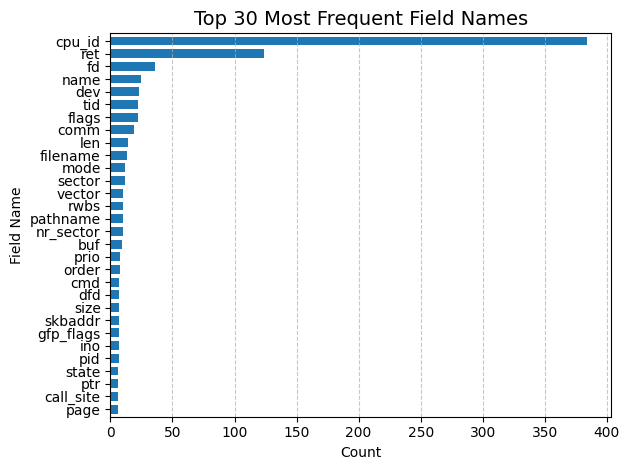

In [31]:
top_n = 30
df_top = df_fields.sort_values('count', ascending=False).head(top_n)

plt.figure(figsize=(10, top_n * 0.3))
df_top.sort_values('count').plot(kind='barh', legend=False, width=0.7)
plt.title(f"Top {top_n} Most Frequent Field Names", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Field Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, max(6, len(df_fields) * 0.3)))
df_fields['count'].plot(kind='barh', log=True)
plt.title("Log-Scaled Frequency Distribution of Field Names")
plt.xlabel("Log(Count)")
plt.ylabel("Field Name")
plt.tight_layout()
plt.show()


In [ ]:
df_cum = df_fields.sort_values('count', ascending=False)
df_cum['cumulative'] = df_cum['count'].cumsum() / df_cum['count'].sum()

plt.figure(figsize=(10, 5))
plt.plot(df_cum['cumulative'].values)
plt.title("Cumulative Distribution of Field Frequencies")
plt.xlabel("Field Rank")
plt.ylabel("Cumulative Share")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
import pyarrow.parquet as pq

# Set display option to avoid scientific notation
pd.set_option('display.float_format', '{:.10f}'.format)

pq_path = r"parquet_test/test2.parquet"
start, stop = 0, 20

pf = pq.ParquetFile(pq_path)
tbl = pf.read()
df = tbl.to_pandas().iloc[start:stop]

display(df)

,line_idx,ts_str,delta_s,t_rel_ns,event_name,event_id,cpu_id,tid,pid,comm,ret,fd,filename,flags,state,extra_params
0,0,08:46:31.491346508,0.0000000000,0,kmem_kmalloc,20,1,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064615, ""ptr"": 184..."
1,1,08:46:31.491349294,0.0000027860,2786,kmem_kfree,19,1,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064826, ""ptr"": 184..."
2,2,08:46:31.491349830,0.0000005360,3322,sched_waking,33,1,2208.0000000000,NaN,lttng-consumerd,NaN,NaN,None,None,NaN,"{""prio"": 20, ""target_cpu"": 2}"
3,3,08:46:31.491350638,0.0000008080,4130,sched_wakeup,34,1,2208.0000000000,NaN,lttng-consumerd,NaN,NaN,None,None,NaN,"{""prio"": 20, ""target_cpu"": 2}"
4,4,08:46:31.491351270,0.0000006320,4762,power_cpu_idle,23,2,NaN,NaN,None,NaN,NaN,None,None,4294967295.0000000000,None
5,5,08:46:31.491351780,0.0000005100,5272,kmem_kmalloc,20,1,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064615, ""ptr"": 184..."
6,6,08:46:31.491352158,0.0000003780,5650,rcu_utilization,18,2,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""s"": ""Start context switch""}"
7,7,08:46:31.491352473,0.0000003150,5965,rcu_utilization,18,2,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""s"": ""End context switch""}"
8,8,08:46:31.491352764,0.0000002910,6256,sched_switch,25,2,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""prev_comm"": ""swapper/2"", ""prev_tid"": 0, ""pre..."
9,9,08:46:31.491352886,0.0000001220,6378,kmem_kfree,19,1,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064826, ""ptr"": 184..."
